In [ ]:
!pip install opencv-python-headless imgaug tensorflow

In [ ]:
!pip install keras_vggface
!pip install tensorflow
!pip install keras-applications
!pip install --upgrade keras
!pip install facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.5 M

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

# Path to the zip file
zip_path = '/content/Facial Dataset.zip'
extract_path = '/content/'

# Extract using shutil
shutil.unpack_archive(zip_path, extract_path)

print("Dataset successfully extracted using shutil.")

Dataset successfully extracted using shutil.


In [ ]:
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
import cv2
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from torchvision import transforms
import imgaug.augmenters as iaa

# Initialize MTCNN face detector
mtcnn = MTCNN()

# Initialize InceptionResnetV1 (FaceNet) for face recognition
model = InceptionResnetV1(pretrained='vggface2').eval()

# Define the image transformation pipeline (resize, to tensor, normalize)
transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert image from NumPy to PIL Image
    transforms.Resize((160, 160)),  # Resize the image to 160x160
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to range [-1, 1]
])

# Define image augmentation pipeline using imgaug
augmentation = iaa.Sequential([
    iaa.Fliplr(0.5),  # 50% chance to flip the image horizontally
    iaa.Affine(rotate=(-10, 10)),  # Randomly rotate images between -10 and 10 degrees
    iaa.Multiply((0.8, 1.2)),  # Randomly adjust the brightness
    iaa.GaussianBlur(sigma=(0, 3.0)),  # Apply random Gaussian blur
])

# Path to the dataset
dataset_path = '/content/Facial Dataset'

def load_and_generate_embeddings(folder_path):
    embeddings = []
    labels = []

    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)

        if os.path.isdir(label_path):
            for file_name in os.listdir(label_path):
                file_path = os.path.join(label_path, file_name)

                img = cv2.imread(file_path)
                if img is not None:
                    # Detect faces using MTCNN
                    faces, probs = mtcnn.detect(img)

                    if faces is not None:
                        for face in faces:
                            # Crop and align the face
                            cropped_face = img[int(face[1]):int(face[3]), int(face[0]):int(face[2])]

                            # Apply augmentation (flip, rotate, brightness, etc.)
                            augmented_face = augmentation(image=cropped_face)

                            # Apply the transformations: resize, convert to tensor, and normalize
                            augmented_face = transform(augmented_face)
                            augmented_face = augmented_face.unsqueeze(0)  # Add batch dimension

                            # Generate the face embedding using FaceNet
                            embedding = model(augmented_face).detach().numpy().flatten()  # Flatten the embedding
                            embeddings.append(embedding)
                            labels.append(label)

    return np.array(embeddings), np.array(labels)




  0%|          | 0.00/107M [00:00<?, ?B/s]

In [ ]:
# Load dataset and generate embeddings
dataset_path = '/content/Facial Dataset'
embeddings, labels = load_and_generate_embeddings(dataset_path)
print(f"Generated embeddings for {len(embeddings)} faces.")

# Check embeddings and labels
if len(embeddings) == 0:
    raise ValueError("No embeddings were generated. Please check your dataset or face detection step.")

if len(labels) != len(embeddings):
    raise ValueError("The number of labels does not match the number of embeddings.")

# Ensure embeddings is a 2D array
embeddings = np.array(embeddings)
if len(embeddings.shape) != 2:
    print("Reshaping embeddings...")
    embeddings = embeddings.reshape(-1, embeddings[0].shape[0])

# Encode the labels (names of people) into numeric values
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

# Train an SVM classifier
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(embeddings, encoded_labels)
accuracy = svm_classifier.score(embeddings, encoded_labels)
print(f"SVM classifier trained with accuracy: {accuracy}")
print("SVM classifier trained.")


Generated embeddings for 118 faces.
SVM classifier trained with accuracy: 0.9322033898305084
SVM classifier trained.


In [ ]:
def predict_image(image_path):
    img = cv2.imread(image_path)

    # Detect faces using MTCNN
    faces, _ = mtcnn.detect(img)

    if faces is not None:
        for face in faces:
            # Crop and preprocess the face
            cropped_face = img[int(face[1]):int(face[3]), int(face[0]):int(face[2])]

            # Apply transformations (resize, normalize, tensor)
            transformed_face = transform(cropped_face)
            transformed_face = transformed_face.unsqueeze(0)  # Add batch dimension (1, 3, 160, 160)

            # Generate embedding
            embedding = model(transformed_face).detach().numpy().flatten()

            # Predict label using SVM
            prediction = svm_classifier.predict([embedding])
            predicted_label = le.inverse_transform(prediction)[0]
            return predicted_label

    else:
        return "No face detected in the image."

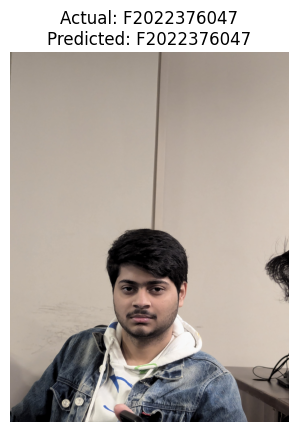

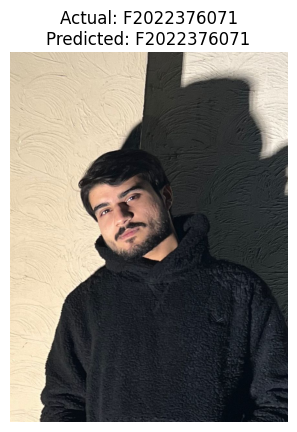

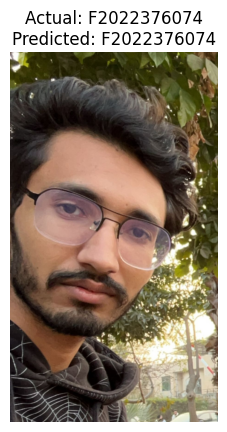

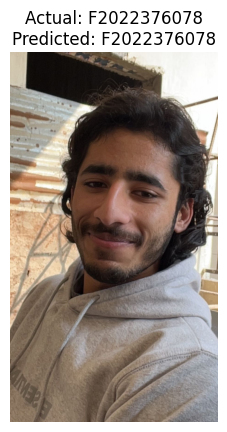

In [ ]:
import matplotlib.pyplot as plt

# Test image paths and actual labels
test_images = [
    ('/content/F2022376047.jpg', 'F2022376047'),
    ('/content/F2022376071.jpg', 'F2022376071'),
    ('/content/F2022376074.jpg', 'F2022376074'),
    ('/content/F2022376078.jpg', 'F2022376078')
]

def predict_and_visualize(image_path, actual_label):
    # Predict the label
    predicted_label = predict_image(image_path)

    # Load the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for visualization

    # Plot the image with labels
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.show()

# Visualize all test images
for img_path, actual_label in test_images:
    predict_and_visualize(img_path, actual_label)


In [ ]:
import joblib

# Save the trained SVM model
joblib.dump(svm_classifier, 'svm_model.pkl')

['svm_model.pkl']

In [ ]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']